Хотелось бы сразу сделать ремарку: мы рассматриваем оценки из Кинопоиска в рамках именно оценок российской аудитории, хотя в ряде других стран СНГ он тоже доступен. Однако там действуют (или могут действовать) другие лицензионные правила, что напрямую влияет на список доступного контента. Из-за таких возможных различий будем считать, что полученные оценки с КП отражают популярность кино среди российской аудитории (в большинстве своем так и есть, так как именно пользователи из РФ преобладают).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [73]:
df = pd.read_excel(r'C:\Users\Asus\Downloads\Telegram Desktop\total_df.xlsx', index_col=0)

In [4]:
df.head()

,level_0,russian_title,english_title_kinopoisk,rating,vote_count_kinopoisk,genre,director,is_film,start_year,end_year,...,genre_tmdb_2,genre_tmdb_3,genre_tmdb_4,genre_tmdb_5,budget_tmdb,revenue_tmdb,company_creater_tmdb,buy_tmdb,rent_tmdb,keywords_tmdb
0,0,1+1,Intouchables,8.9,2791000.0,драма,Оливье Накаш,1.0,2011.0,NaN,...,35.0,NaN,NaN,NaN,13000000.0,426590315.0,NaN,[],[],NaN
1,1,Джентльмены,The Gentlemen,8.7,2473000.0,криминал,Гай Ричи,1.0,2019.0,NaN,...,80.0,NaN,NaN,NaN,22000000.0,115171795.0,NaN,"['Apple TV Store', 'Google Play Movies']","['Apple TV Store', 'Google Play Movies']",NaN
2,3,Гнев человеческий,Wrath of Man,7.7,1751000.0,боевик,Гай Ричи,1.0,2021.0,NaN,...,80.0,18.0,NaN,NaN,40000000.0,103966489.0,NaN,"['Apple TV Store', 'Google Play Movies', 'Kino...","['Apple TV Store', 'Google Play Movies']",NaN
3,4,Волк с Уолл-стрит,The Wolf of Wall Street,8.1,1716000.0,драма,Мартин Скорсезе,1.0,2013.0,NaN,...,18.0,35.0,NaN,NaN,100000000.0,407038432.0,NaN,[],[],NaN
4,5,Игра престолов,Game of Thrones,9.0,1497000.0,фэнтези,Дэвид Наттер,0.0,2011.0,2011.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[],NaN


In [74]:
# избавимся от мусорного стобца индекса, от повторяющейся колокни с названием и внутреннего индекса кино в tmdb
df = df.drop(['level_0', 'english_title_tmdb', 'id_tmdb'], axis=1)

In [25]:
df.shape

(41367, 29)

In [26]:
df.columns

Index(['russian_title', 'english_title_kinopoisk', 'rating',
       'vote_count_kinopoisk', 'genre', 'director', 'is_film', 'start_year',
       'end_year', 'duration_minutes', 'country', 'actors', 'overview_tmdb',
       'release_date', 'genre_ids_tmdb', 'popularity_tmdb',
       'vote_average_tmdb', 'vote_count_tmdb', 'genre_tmdb_1', 'genre_tmdb_2',
       'genre_tmdb_3', 'genre_tmdb_4', 'genre_tmdb_5', 'budget_tmdb',
       'revenue_tmdb', 'company_creater_tmdb', 'buy_tmdb', 'rent_tmdb',
       'keywords_tmdb'],
      dtype='str')

In [27]:
df.describe()

,rating,vote_count_kinopoisk,is_film,start_year,end_year,duration_minutes,popularity_tmdb,vote_average_tmdb,vote_count_tmdb,genre_tmdb_1,genre_tmdb_2,genre_tmdb_3,genre_tmdb_4,genre_tmdb_5,budget_tmdb,revenue_tmdb
count,38968.000000,3.896800e+04,41159.000000,35379.000000,5024.000000,30355.000000,41196.000000,31401.000000,31401.000000,31194.000000,24367.000000,13716.000000,4119.000000,1078.000000,2.148800e+04,2.263100e+04
mean,6.618246,2.216388e+04,0.737506,2004.863620,2011.752588,99.833569,2.862898,5.860497,897.998758,1127.339328,2396.113884,2842.544109,3080.115076,3513.760668,1.589098e+07,4.730666e+07
std,1.020210,7.516101e+04,0.439995,19.375323,11.276796,27.496010,14.939668,1.782948,2661.239931,3186.802530,4356.403211,4592.695396,4715.003059,4889.913867,3.660162e+07,1.586581e+08
min,1.200000,3.520000e+02,0.000000,1890.000000,1951.000000,1.000000,0.000000,0.000000,0.000000,12.000000,12.000000,12.000000,12.000000,12.000000,0.000000e+00,0.000000e+00
25%,6.100000,7.630000e+02,0.000000,1998.000000,2007.000000,89.000000,0.051100,5.483000,31.000000,18.000000,18.000000,18.000000,18.000000,18.000000,0.000000e+00,0.000000e+00
50%,6.700000,2.131000e+03,1.000000,2011.000000,2015.000000,98.000000,0.951950,6.205000,119.000000,28.000000,35.000000,53.000000,53.000000,53.000000,5.000000e+05,2.821910e+05
75%,7.300000,1.063800e+04,1.000000,2018.000000,2020.000000,111.000000,2.071475,6.900000,488.000000,36.000000,878.000000,9648.000000,9648.000000,10749.000000,1.500000e+07,1.978481e+07
max,9.300000,2.791000e+06,1.000000,2026.000000,2026.000000,776.000000,929.516300,10.000000,39327.000000,10770.000000,10770.000000,10770.000000,10770.000000,10770.000000,4.899000e+08,2.799439e+09


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41367 entries, 0 to 41366
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   russian_title            41367 non-null  str    
 1   english_title_kinopoisk  40806 non-null  str    
 2   rating                   38968 non-null  float64
 3   vote_count_kinopoisk     38968 non-null  float64
 4   genre                    41355 non-null  str    
 5   director                 40890 non-null  str    
 6   is_film                  41159 non-null  float64
 7   start_year               35379 non-null  float64
 8   end_year                 5024 non-null   float64
 9   duration_minutes         30355 non-null  float64
 10  country                  41363 non-null  str    
 11  actors                   41363 non-null  str    
 12  overview_tmdb            29840 non-null  str    
 13  release_date             31254 non-null  str    
 14  genre_ids_tmdb           31401 no

In [29]:
df.isna().mean().sort_values()*100

russian_title               0.000000
actors                      0.009670
country                     0.009670
genre                       0.029009
popularity_tmdb             0.413373
is_film                     0.502816
director                    1.153093
english_title_kinopoisk     1.356153
rating                      5.799309
vote_count_kinopoisk        5.799309
start_year                 14.475306
genre_ids_tmdb             24.091667
rent_tmdb                  24.091667
buy_tmdb                   24.091667
vote_count_tmdb            24.091667
vote_average_tmdb          24.091667
release_date               24.447023
genre_tmdb_1               24.592066
duration_minutes           26.620253
overview_tmdb              27.865207
genre_tmdb_2               41.095559
revenue_tmdb               45.292141
budget_tmdb                48.055213
genre_tmdb_3               66.843136
company_creater_tmdb       79.561003
end_year                   87.855054
genre_tmdb_4               90.042788
k

колонках жанров, взятых из апи tmdb, представляют из себя что-то похожее на OHE, но у нас уже есть колонка жанров на русском языке - будем ориентироваться по ней (тем более по жанрам из апи tmdb слишком много пропусков - 24%, по сравнению с КП - 0.02%)

In [75]:
df = df.drop(['genre_tmdb_1','genre_tmdb_2','genre_tmdb_3','genre_tmdb_4','genre_tmdb_5','genre_ids_tmdb'], axis=1)

в колонках keywords_tmdb, company_creater_tmdb непозволятельно много пропусков - 95% и 80% соответственно, из них мы сможем мало что вычленить интересного для анализа, поэтому их тоже удалим

In [76]:
df = df.drop(['keywords_tmdb','company_creater_tmdb'], axis=1)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41367 entries, 0 to 41366
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   russian_title            41367 non-null  str    
 1   english_title_kinopoisk  40806 non-null  str    
 2   rating                   38968 non-null  float64
 3   vote_count_kinopoisk     38968 non-null  float64
 4   genre                    41355 non-null  str    
 5   director                 40890 non-null  str    
 6   is_film                  41159 non-null  float64
 7   start_year               35379 non-null  float64
 8   end_year                 5024 non-null   float64
 9   duration_minutes         30355 non-null  float64
 10  country                  41363 non-null  str    
 11  actors                   41363 non-null  str    
 12  overview_tmdb            29840 non-null  str    
 13  release_date             31254 non-null  str    
 14  popularity_tmdb          41196 no

# Закупка русским стримингом лицензий зарубежных фильмов

В этом бизнес-теме мы будем делать анализ нашего датасета относительно того, насколько схожа популярность кино в мире (оценки из TMDB API) с популярностью этого же кино в России (оценки из кинопоиска). Самый главный рычаг давления на выбор стримингом списка покупаемых лицензий - бюджет. Надо исследовать вопрос соотношения популярности кино в двух реалиях (мир и Россия).

Тут может быть два исхода:
- фильмы и сериалы, которых по миру оценили высоко, а в России ниже, переоценены зарубежным рынком или просто не подходит под русский нрав - лицензии на такое кино лучше не покупать
- кино, которое по миру оценили ниже, чем в России, недооценено - именно на такие фильмы и сериалы нужно покупать лицензии: они будут стоить дешево из-за низких оценок, а приносить большую прибыль по сравнению с первым вариантом

Откуда появилась идея такой темы? \
-> Просто взглянув на первую строчку нашего датасета можно увидеть уже различия рынков кино мира и России - рейтинг на КП (8.9) заметно выше, чем на TMDB (~8.27), а также сильное различие в количество оценок: КП - около 2,8 миллионов, tmdb - всего 18к. Такая коллосальная разница в количестве оценок и значительное превосходство оценки на КП может вывести нас на гипотезу, что фильм '1+1' стал для нашей страны культовым, таким кино, которое чуть ли не формирует отдельный культурный отпечаток нашей страны. И правда - очень сложно найти в своем окружении человека, которому не понравился этот фильм, а тем более несмотревшего его.

In [37]:
df[df['russian_title']=='1+1'][['russian_title','rating','vote_count_kinopoisk','vote_average_tmdb','vote_count_tmdb']].T

,0
russian_title,1+1
rating,8.9
vote_count_kinopoisk,2791000.0
vote_average_tmdb,8.269
vote_count_tmdb,18279.0


In [53]:
# для начала оценим популярность по самому очевидному - средней оценке платформы
fig = px.scatter(df, x='rating', y='vote_average_tmdb', hover_name='russian_title', 
                 labels={'rating': 'Оценка на Кинопоиске', 'vote_average_tmdb': 'Оценка на TMDB'},
                 title='Соотношение популярности кино в РФ и мире кино по оценкам')
fig.add_trace(go.Scatter(x=[0,10],y=[0,10], mode='lines', name='y=x (Оценки совпадают)'))
fig.show()

По графику видна в принципе положительная корреляция и видно, что преобладают оценки из средней зоны - что логично, так как парсинг данных (что является фундаментом наших данных) проводился по первым 1000 страницам рейтинга лучшего кино на Кинопоиске, то есть фильмы и сериалы с плохими оценками попали в датасет в малом количестве.

Красная линия отображает границу фильмов и сериалов, по которой мы должны определять как раз нашу цель:
- выше красной: в России кино оценили ниже мирового рынка -> переоценка мировым рынком -> лучше не покупать лицензию
- ниже красной: в России кино оценили выше мирового рынка -> недооценка мировым рынком -> надо покупать лицензию

Если конкретнее, то мы наблюдаем сильный разброс как раз в этих средних оценках (4-8), а также можно заметить, что на КП нет оценок выше 9.3 (единственное такое кино - Hot wheels, ха-ха). А также есть ряд фильмов, у которых по какой-то причине отсутствуют значения оценок на tmdb (у них 0).

In [45]:
# посмотрим на фильмы с оценкой 0 на tmdb
df[df['vote_average_tmdb']==0]

,russian_title,english_title_kinopoisk,rating,vote_count_kinopoisk,genre,director,is_film,start_year,end_year,duration_minutes,...,actors,overview_tmdb,release_date,popularity_tmdb,vote_average_tmdb,vote_count_tmdb,budget_tmdb,revenue_tmdb,buy_tmdb,rent_tmdb
47,Рататуй,Ratatouille,8.1,815033.0,мультфильм,Брэд Бёрд,1.0,2007.0,NaN,111.0,...,Пэттон Освальт|Иэн Холм,Жулики похищают из музея картину Айвазовского ...,2006-06-06,0.5267,0.0,0.0,NaN,NaN,[],[]
95,Такси,Taxi,8.0,654516.0,боевик,Жерар Пирес,1.0,1998.0,NaN,89.0,...,Сами Насери|Фредерик Дифенталь,NaN,2015-01-01,0.1464,0.0,0.0,NaN,NaN,[],[]
201,Красотка,Pretty Woman,8.0,506827.0,мелодрама,Гэрри Маршалл,1.0,1990.0,NaN,115.0,...,Ричард Гир|Джулия Робертс,"Кирилл, молодой успешный предприниматель, приг...",2013-03-26,0.6805,0.0,0.0,NaN,NaN,[],[]
222,Пассажиры,Passengers,7.2,483009.0,фантастика,Мортен Тильдум,1.0,2016.0,NaN,116.0,...,Крис Пратт|Дженнифер Лоуренс,Террористы захватывают автобус с больными людь...,2024-10-17,0.3931,0.0,0.0,NaN,14720.0,[],[]
247,Никто,Nobody,7.4,461843.0,боевик,Илья Найшуллер,1.0,2021.0,NaN,92.0,...,Боб Оденкёрк|Алексей Серебряков,"О том, как пережить разлуку с любимым, об утра...",NaN,0.2774,0.0,0.0,NaN,NaN,[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41312,Детская площадка,Plac zabaw,5.3,353.0,триллер,Бартош Ковальски,1.0,2016.0,NaN,82.0,...,Michalina Swistun|Николас Пшигода,Живущие без родителей Жанна и Роман еще почти ...,1987-06-01,0.4402,0.0,0.0,NaN,NaN,[],[]
41319,Легенда об Энио,Legend of Enyo,NaN,NaN,мультфильм,Марк Зоннтаг,0.0,2009.0,2009.0,NaN,...,Джэми Крофт|Пиппа Грэндисон,"Деревянный конь, символ греческого вероломства...",1962-01-01,NaN,0.0,0.0,NaN,NaN,[],[]
41327,Два пистолета. Неуловимый Бриллиант,NaN,5.3,353.0,комедия,Денис Куклин,NaN,NaN,NaN,NaN,...,Данил Волковинский|Даулет Абдыгапаров,NaN,2011-03-17,0.2525,0.0,0.0,NaN,NaN,[],[]
41345,Верными останемся,Vernymi ostanemsya,NaN,NaN,драма,Андрей Малюков,1.0,1988.0,NaN,192.0,...,Игорь Волков|Елена Яковлева,В основе сюжета кинодилогии - исследование сло...,1989-03-27,0.5589,0.0,0.0,NaN,NaN,[],[]


In [ ]:
# сколько русского кино имеет оценку 0 на tmdb
df[(df['vote_average_tmdb']==0) & (df['country']=='Россия')].shape[0]

19

In [ ]:
# сколько НЕамериканских фильмов имеют оценку 0 на tmdb
df[(df['vote_average_tmdb']==0) & (df['country']!='США')].shape[0]

1236

по началу пришла в голову идея, что такие фильмы были сняты в России, поэтому не представлены на tmdb и поэтому не имеют никакой информации, но это оказалось не совсем так - большинство фильмов с 0 оценкой просто были произведены не в Америке, а tmdb был зарегистрирован пользователем из США, и, возможно, с некоторыми зарубежными фильмами случилась ошибка перенесения данных - ведь к тому же данный апи tmdb является глобальным и дополняется людьми со всего мира, поэтому тут тоже могут возникнуть ошибки из-за мискоммуникации

In [ ]:
# теперь сравним по количеству оценок
fig = px.scatter(df, x='vote_count_tmdb', y='vote_count_kinopoisk', hover_name='russian_title',
                 labels={'vote_count_tmdb': 'Кол-во оценок на Кинопоиске', 'vote_count_kinopoisk': 'Кол-во оценок на TMDB'},
                 title='Соотношение популярности кино в РФ и мире по количеству оценок')
fig.show()

Тут мы замечаем, что кол-во оценок у фильмов из tmdb в принципе намного ниже кол-ва оценок на КП. Это произошло из-за уже ранее описанных проблем самой базы данных TMDB (опенсорс), а также неполной официальности источника по сравнению с каким-нибудь IMDB. Но почему мы не взяли его апи? Потому что оно закрытое, ориентировано на бизнес-клиентов и стоит дорого, а мы студенты...

-----

Теперь посмотрим более конкретнее на расхождения в оценках - для этого введем новое поле разницы значений средних оценок на двух платформах

In [81]:
notnan_ratings = df[df['rating'].notna() & df['vote_average_tmdb'].notna()]
notnan_ratings['rating_diff'] = notnan_ratings['rating'] - notnan_ratings['vote_average_tmdb']

In [82]:
df.shape, notnan_ratings.shape

((41367, 22), (30278, 22))

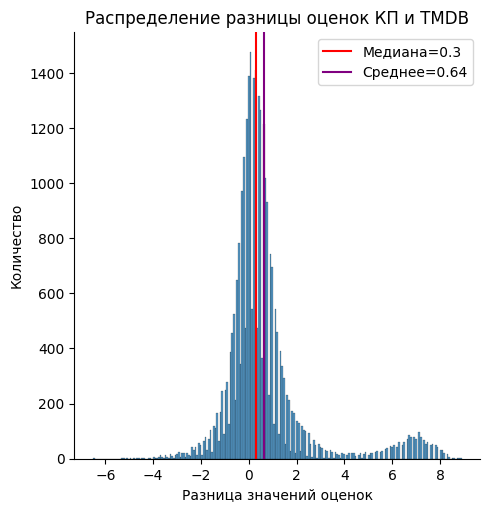

In [83]:
sns.displot(notnan_ratings['rating_diff'])
median_diff=notnan_ratings['rating_diff'].median()
mean_diff=notnan_ratings['rating_diff'].mean()
plt.axvline(median_diff, color='red', label=f'Медиана={round(median_diff,2)}')
plt.axvline(mean_diff, color='purple', label=f'Среднее={round(mean_diff,2)}')
plt.title('Распределение разницы оценок КП и TMDB')
plt.xlabel('Разница значений оценок')
plt.ylabel('Количество')
plt.legend()
plt.show()

Если рассматривать разницу оценок как случайную велечину (непрерывную), то ее распределение достаточно хорошо похоже на нормальное - только вытянутое вверх (сам колокол) и имеет тяжелый хвост справа.

По графику можно сказать, что в большинстве случаев (значения в колоколе) нет отличий оценок, но нам центральная часть и неинтересна - для бизнеса важен именно правый хвост, в котором оценки Кинопоиска (российского рынка) выше TMDB (мирового), то есть это те самые лакомые кусочки, которые и стоит приобрести.

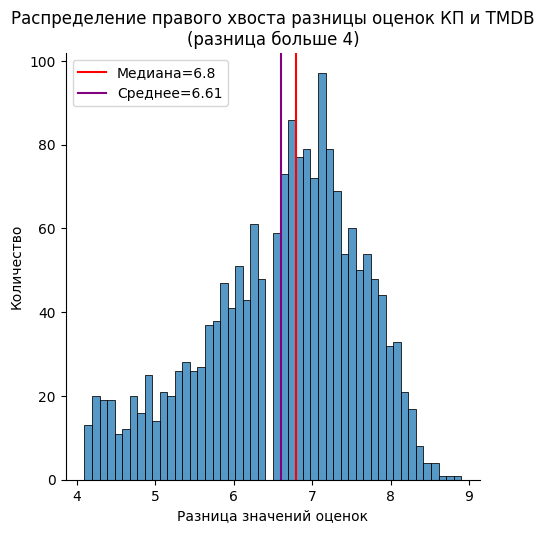

In [84]:
right_tail = notnan_ratings[notnan_ratings['rating_diff']>4]
median_tail=right_tail['rating_diff'].median()
mean_tail=right_tail['rating_diff'].mean()
sns.displot(right_tail['rating_diff'], bins=50)
plt.axvline(median_tail, color='red', label=f'Медиана={round(median_tail,2)}')
plt.axvline(mean_tail, color='purple', label=f'Среднее={round(mean_tail,2)}')
plt.title('Распределение правого хвоста разницы оценок КП и TMDB\n(разница больше 4)')
plt.xlabel('Разница значений оценок')
plt.ylabel('Количество')
plt.legend()
plt.show()

В данную выборку данных у нас попало кино, которое зрители платформы КП оценили в среднем на 6.6-6.8 выше, чем это сделали люди с оценками на TMDB. Но не стоит так сильно радоваться, ведь мы не избавились от проблемы, что у некоторых фильмов просто нет достаточно информации на ресурсе tmdb. Не может быть таким высоким это среднее: если у каждого такого кино оценка на КП выше на 7, то оценка tmdb должна быть где-то в диапазоне 0-2.3 (макс оценка на КП - 9.3). А для фильмов которые вообще правее значения 7 на графике так вообще оценка tmdb стремится к 0. Это очень подозрительный разрыв. Поэтому проверим, а насколько вообще широки группы оценивающей аудитории

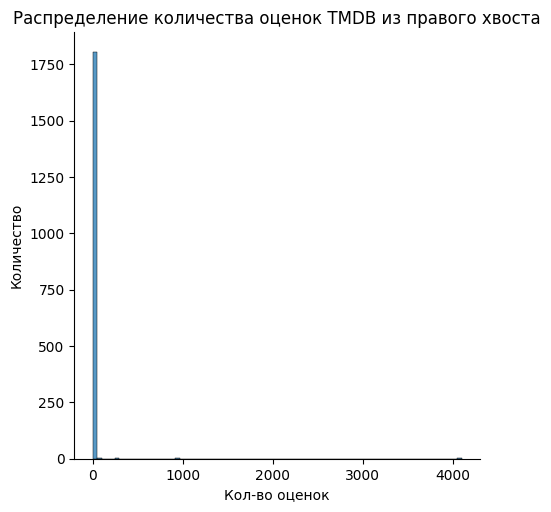

In [39]:
sns.displot(right_tail['vote_count_tmdb'])
plt.title('Распределение количества оценок TMDB из правого хвоста')
plt.xlabel('Кол-во оценок')
plt.ylabel('Количество')
plt.show()

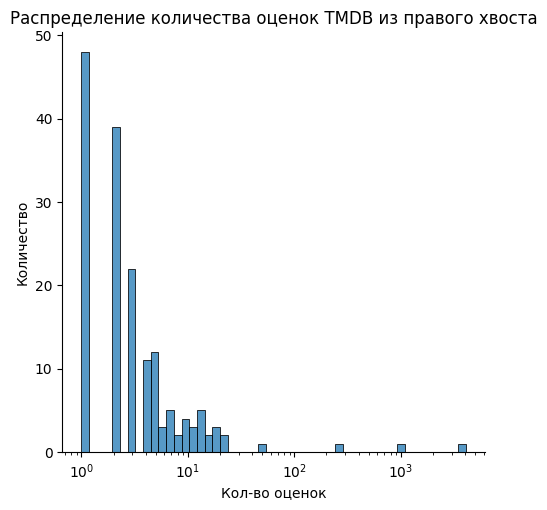

In [41]:
sns.displot(right_tail['vote_count_tmdb'], log_scale=True, bins=50)
plt.title('Распределение количества оценок TMDB из правого хвоста')
plt.xlabel('Кол-во оценок')
plt.ylabel('Количество')
plt.show()

Подтвердил свою гипотезу, что у нас что-то не так с выборками людей, теперь оставим только более менее репрезентативные группы: от 500 человек и больше.

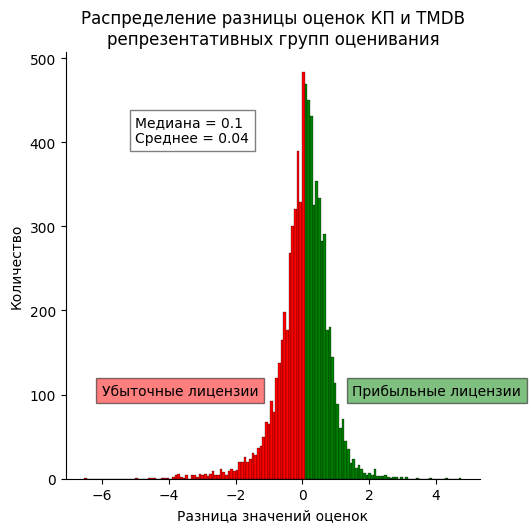

In [85]:
representative = notnan_ratings[notnan_ratings['vote_count_tmdb']>500]
graph = sns.displot(representative['rating_diff'])
ax = graph.ax
for rectangle in ax.patches:
    rectangle.set_facecolor('red') if rectangle.get_x()<0 else rectangle.set_facecolor('green')

plt.text(x=-5, y=400, s=f"Медиана = {round(representative['rating_diff'].median(),2)}\nСреднее = {round(representative['rating_diff'].mean(),2)}",
         bbox={'facecolor': 'white', 'alpha': 0.5})
plt.text(x=-6, y=100, s='Убыточные лицензии',
         bbox={'facecolor': 'red', 'alpha': 0.5})
plt.text(x=1.5, y=100, s='Прибыльные лицензии',
         bbox={'facecolor': 'green', 'alpha': 0.5})
plt.title('Распределение разницы оценок КП и TMDB\nрепрезентативных групп оценивания')
plt.xlabel('Разница значений оценок')
plt.ylabel('Количество')
plt.show()

Теперь наше распределение избавилось от выбросов с правой стороны, благодаря чему у нас выровнялись медиана и среднее, и стали равными практически 0. Из чего можно сделать вывод, что в большинстве своем пользователи двух площадок оценивают кино одинаково, а следовательно любое отклонение разницы оценок в положительную сторону уже даст нужный эффект "недооценки", а в отрицательную "переоценки".

Если коротко:
- все, что справа, мы рассматриваем как покупку лицензии с прибыльностью (относительно мирового рынка)
- все, что слева, мы рассматриваем как покупку лицензии с убыточностью (относительно мирового рынка)

Кстати, после проведения чистки стал более заметен левый хвост, что может означать, что отдел закупки лицензий реже угадывает с нужными лицензиями кино, у которых сильная разница между оценками

In [86]:
rating = representative.sort_values('rating_diff')

In [87]:
# Топ-100 кино, лицензию которых стоит купить
rating[-100:].head()

,russian_title,english_title_kinopoisk,rating,vote_count_kinopoisk,genre,director,is_film,start_year,end_year,duration_minutes,...,overview_tmdb,release_date,popularity_tmdb,vote_average_tmdb,vote_count_tmdb,budget_tmdb,revenue_tmdb,buy_tmdb,rent_tmdb,rating_diff
405,Секс в большом городе,Sex and the City,8.2,348931.0,драма,Майкл Патрик Кинг,0.0,1998.0,1998.0,NaN,...,Героини сериала «Секс в большом городе» вновь ...,2008-05-12,6.7310,6.6,2249.0,65000000.0,418800000.0,[],[],1.6
4290,Кэнди,Candy,7.6,42341.0,драма,Нил Армфилд,1.0,2005.0,NaN,104.0,...,В поисках идей молодой художник из Чикаго Энто...,2021-08-25,2.8838,6.0,1741.0,25000000.0,77411570.0,"['Apple TV Store', 'Google Play Movies']",[],1.6
31270,Таинственные пути,Mysterious Ways,7.7,691.0,фантастика,Кен Джабенвиль,0.0,2000.0,2000.0,NaN,...,На этот раз Шон Андерсон получает закодированн...,2012-01-19,5.8980,6.1,4476.0,79000000.0,355692760.0,[],[],1.6
8749,Хороший мальчик,Gutboi,8.3,13208.0,боевик,Щим На-ён,0.0,NaN,NaN,NaN,...,Владелец пса Инди страдает от серьёзной болезн...,2025-10-01,9.1221,6.7,575.0,70000.0,8844724.0,[],[],1.6
2868,По волчьим законам,Animal Kingdom,8.4,71051.0,драма,Ник Копус,0.0,2016.0,2016.0,NaN,...,Криминальная драма о войне подпольных группиро...,2010-06-03,3.7199,6.8,900.0,5000000.0,1000000.0,[],[],1.6


In [88]:
# Топ-100 кино, лицензию которых НЕ стоит купить
rating[:100].head()

,russian_title,english_title_kinopoisk,rating,vote_count_kinopoisk,genre,director,is_film,start_year,end_year,duration_minutes,...,overview_tmdb,release_date,popularity_tmdb,vote_average_tmdb,vote_count_tmdb,budget_tmdb,revenue_tmdb,buy_tmdb,rent_tmdb,rating_diff
22237,Темный рыцарь: Возвращение,The Black Knight Returns,1.4,1580.0,фантастика,Хуан Авилез,1.0,2009.0,NaN,87.0,...,Прошло 10 лет с тех пор как стареющий Бэтмен «...,2013-01-03,3.9835,7.926,1586.0,3500000.0,NaN,[],[],-6.526
39765,13/13/13,13/13/13,2.5,387.0,ужасы,Джеймс Каллен Брэссак,1.0,2013.0,NaN,86.0,...,Фильм о неудачной лунной миссии «Аполлон-13» —...,1995-06-30,13.8455,7.454,5819.0,52000000.0,355237933.0,"['Apple TV Store', 'Google Play Movies']","['Apple TV Store', 'Google Play Movies']",-4.954
34151,Война планет,Terrarium,2.6,559.0,фантастика,Майк Конуэй,1.0,2003.0,NaN,81.0,...,Армию генетически модифицированных обезьян ожи...,2017-07-11,8.8224,7.219,9655.0,150000000.0,490719763.0,['Kinopoisk'],[],-4.619
30992,Человек-змея,The Snake King,2.5,707.0,ужасы,Аллан А. Голдштейн,1.0,2005.0,NaN,90.0,...,"За много лет до того, как стать тираническим п...",2023-11-15,8.0173,6.984,3444.0,100000000.0,337371917.0,[],[],-4.484
30799,Могилы,The Graves,3.1,718.0,ужасы,Брайан Пулидо,1.0,2009.0,NaN,89.0,...,Проживающая в Лос-Анджелесе богатая семья коре...,2024-02-22,8.7921,7.498,648.0,NaN,97974828.0,['Okko'],['Okko'],-4.398
